# Tracing every paper number to saved results — iteration-5 audit (demo)

This notebook is a runnable walk-through of the **analysis-only audit** (`eval.py`) behind the paper
*Does Slovene-taught refusal survive?* (GaMS3 vs Gemma 3). The audit made **no new generations and no paid judge calls**
($0 OpenRouter). It re-derives the numbers the iteration-4 paper reported from the saved outputs of earlier
experiments and applies decision rules that were **frozen in `protocol_eval.yaml` before any computation**.
Because the analyses are post hoc, those rules can *downgrade* a claim but never confirm a new one.

The original `eval.py` is an orchestrator. It runs seven step modules (`src/ceiling.py`, `src/kl_excess.py`,
`src/decomposition.py`, `src/exp14_tables.py`, `src/ledger.py`, `src/owed.py`, `src/make_tables.py`), and then
`build_eval_out()` collects the headline metrics from `results/*.json`. Most steps read large upstream files: 47 MB
of exp15 rows, eval3 parquet frames and the paper draft. This demo therefore does two things:

1. **Re-runs Step 1 (ceiling sensitivity of exp15's baseline offset `G3_orig`) from scratch.** The input is the
   item-level λ = 0 refusal labels (300 items × 2 models × 2 languages), and the code is copied from
   `src/ceiling.py` / `src/common.py`. This is the step that turned *"GaMS3 refuses relatively less in Slovene
   at baseline"* into **CEILING-ARTEFACT**.
2. **Runs `eval.py`'s own `build_eval_out()`** on the saved step outputs (trimmed copies of `results/*.json`). With
   the recomputed Step-1 values swapped in, it rebuilds every headline metric: KL-excess verdicts, the
   decomposition, the exp14 table cross-check, the correction ledger, criterion shift and exp13.

Key quantities:
* `M0 = logit_H(SL refusal) − logit_H(EN refusal)` per model at λ = 0, where `logit_H` is the Hautus log-linear
  logit `ln((k+.5)/(n−k+.5))`.
* `G3_orig = M0_GaMS3 − M0_Gemma`, the baseline (unedited) language gap difference. The margin of practical
  equivalence is `m = 0.675`.
* **Fragility index `FI_m`** is the minimum number of single-label flips that moves `G3_orig` inside `(−m, +m)`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (the original scripts log through it)
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
These combine the import blocks of `eval.py`, `src/common.py` and `src/ceiling.py`. The only addition is matplotlib,
which the final visualisation cell uses. The `argparse` / `subprocess` / `resource` imports and the `sys.path` /
`import ceiling ...` module imports of `eval.py` are dropped: the step code is inlined in the cells below, and
there is no CLI.

In [2]:
from __future__ import annotations

import itertools
import json
import math
import sys
import time
from collections import defaultdict
from typing import Any, Iterable

import numpy as np
import pandas as pd
from loguru import logger
from scipy import special, stats

import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|demo|{message}")

1

## Data loading
`mini_demo_data.json` has two parts:
* `exp15_lambda0`: 1,200 rows of λ = 0 labels from the exp15 BODY set (edit `E_exp9`, ladder + fill-in blocks,
  arms `EN_BT` / `SL_MT`), with the J1 raw primary judge label and the author-model adjudication where it exists.
  It also holds the saved per-cell counts, the saved `G3_orig` and the unedited judge-validity cells (Se/Sp).
* `results`: the seven `results/*.json` files that `build_eval_out()` reads, trimmed to the fields it uses. The
  correction ledger keeps its 22 pointer rows plus 78 of its 1,176 token rows, stratified by status × match
  method. Its summary counts still cover all rows.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-2cf2a7-does-slovene-taught-refusal-survive/main/round-5/evaluation-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("exp15 lambda-0 rows:", len(data["exp15_lambda0"]["rows"]), "| items:", data["exp15_lambda0"]["n_items"])
print("saved results files:", list(data["results"]))

exp15 lambda-0 rows: 1200 | items: 300
saved results files: ['ceiling_sensitivity', 'kl_excess', 'decomposition_table', 'correction_ledger', 'step6', 'verify', 'exp14_tables_regenerated']


## Configuration
The Monte-Carlo sizes come from `protocol_eval.yaml` (`B_bootstrap`, `n_permutations`, `n_posterior_draws`,
`leave_k.random_subsets`). The originals are **2000 / 5000 / 200000 / 20000**. With the originals and the frozen
seed, Step 1 reproduces the saved `ceiling_sensitivity.json` exactly, and the check cell below confirms this.
Smaller values run faster but move the interval and p-value estimates. The point estimates, fragility indices
and verdict do not depend on these sizes.

In [5]:
# ---- tunable Monte-Carlo sizes (protocol_eval.yaml originals in comments)
B_BOOT = 2000                      # item bootstrap replicates          (original: 2000)
N_PERM = 5000                      # model-label permutations           (original: 5000)
N_POSTERIOR_DRAWS = 200000          # Jeffreys posterior draws per cell  (original: 200000)
LEAVE_K_RANDOM_SUBSETS = 20000       # random subsets for leave-k, k=3..5 (original: 20000)

# ---- frozen protocol constants (src/common.py; do not change)
SEED = 20260927
B = B_BOOT
M = 0.675
MODELS = ("gemma_it", "gams3_it")

## Shared numeric helpers (`src/common.py`)
Copied verbatim: the Hautus log-linear logit, the percentile CI (which returns `[None, None]` with fewer than 20
finite draws), the Wilson interval and the JSON `clean` helper. The originals also had path constants, file I/O
and hashing helpers. Those are not needed here because the data arrives through `data`.

In [6]:
def rel(p) -> str:
    # notebook stand-in for common.rel: provenance strings stay run-relative
    return str(p)


def clean(o: Any) -> Any:
    '''JSON-safe: numpy -> python, NaN/inf -> None.'''
    if isinstance(o, dict):
        return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        f = float(o)
        return f if math.isfinite(f) else None
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return clean(o.tolist())
    return o


# ------------------------------------------------------------------ rates / logits
def hautus_logit(k, n):
    '''Hautus (1995) log-linear rule on the logit scale: ln((k+.5)/(n-k+.5)) (= Haldane-Anscombe = logit of Jeffreys mean).'''
    k = np.asarray(k, float)
    n = np.asarray(n, float)
    return np.log((k + 0.5) / (n - k + 0.5))


def pct_ci(a: Iterable[float], lo: float = 2.5, hi: float = 97.5) -> list[float | None]:
    a = np.asarray(list(a), float)
    a = a[np.isfinite(a)]
    if len(a) < 20:
        return [None, None]
    return [float(np.percentile(a, lo)), float(np.percentile(a, hi))]


def wilson(k: float, n: float, z: float = 1.96) -> list[float | None]:
    if n <= 0:
        return [None, None]
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return [c - h, c + h]

## Step 1a: core formulas for `G3_orig` and the fragility index (`src/ceiling.py`)
* `g3_orig_counts` computes `G3_orig` from the four cell counts (Gemma/GaMS3 × EN/SL). It supports four
  extreme-proportion estimators: Hautus, Laplace add-1, the 1/(2N) rule, and the Jeffreys posterior mean of the logit.
* `prob_did` is the same contrast on the plain probability scale, in percentage points. It is the ceiling-robust
  view, because a 1-item change near 100% is a tiny probability change but a large logit change.
* `fragility` (Walsh et al. 2014) searches every signed flip allocation over the four cells for flip budgets
  t = 0, 1, 2, …. It returns the smallest t that brings `G3_orig` inside ±m (`FI_m`) and the smallest t that
  reaches 0 (`FI_0`).

In [7]:
CELLS = ("gemma_en", "gemma_sl", "gams_en", "gams_sl")


# ------------------------------------------------------------------ core formulas
def g3_orig_counts(k: dict, n: dict, est: str = "hautus") -> float:
    '''k, n keyed by CELLS. Estimators on the logit scale.'''
    def L(kk, nn):
        if est == "hautus":
            return float(hautus_logit(kk, nn))
        if est == "laplace":
            p = (kk + 1) / (nn + 2)
            return math.log(p / (1 - p))
        if est == "half_n":  # 1/(2N) rule, only for cells at 0 or n (Macmillan & Kaplan 1985)
            p = kk / nn
            if kk <= 0:
                p = 1 / (2 * nn)
            elif kk >= nn:
                p = 1 - 1 / (2 * nn)
            return math.log(p / (1 - p))
        if est == "jeffreys_logit_mean":  # E[logit p] under Beta(k+.5, n-k+.5)
            return float(special.digamma(kk + 0.5) - special.digamma(nn - kk + 0.5))
        raise ValueError(est)
    m_gemma = L(k["gemma_sl"], n["gemma_sl"]) - L(k["gemma_en"], n["gemma_en"])
    m_gams = L(k["gams_sl"], n["gams_sl"]) - L(k["gams_en"], n["gams_en"])
    return m_gams - m_gemma


def prob_did(k: dict, n: dict) -> float:
    '''probability-scale DiD in percentage points: (pS-pE)_GaMS - (pS-pE)_Gemma.'''
    d = lambda a, b: k[a] / n[a] - k[b] / n[b]  # noqa: E731
    return 100 * (d("gams_sl", "gams_en") - d("gemma_sl", "gemma_en"))


def fragility(k: dict, n: dict, est: str = "hautus", max_flips: int = 40) -> dict:
    '''Exact minimum number of single-label flips (REFUSE <-> non-REFUSE, k bounded to [0, n]) that bring G3_orig
    inside (-m, +m) [FI_m] and to zero from its observed side, i.e. a sign change [FI_0]; plus the best reachable G3_orig per flip budget (trajectory).'''
    g0 = g3_orig_counts(k, n, est)
    sign = 1.0 if g0 < 0 else -1.0  # move toward zero
    res = {"G3_orig": g0, "FI_m": None, "FI_0": None, "trajectory": [], "path_at_FI_m": None, "path_at_FI_0": None}
    if abs(g0) < M:
        res["FI_m"] = 0
    if (g0 >= 0 and sign > 0) or (g0 <= 0 and sign < 0):
        res["FI_0"] = 0
    for t in range(0, max_flips + 1):
        best, best_d = -np.inf, None
        # all 4-tuples of signed deltas with sum |d| = t
        for parts in _compositions(t, 4):
            for signs in itertools.product((-1, 1), repeat=4):
                if any(p == 0 and s < 0 for p, s in zip(parts, signs)):
                    continue
                d = {c: s * p for c, p, s in zip(CELLS, parts, signs)}
                kk = {c: k[c] + d[c] for c in CELLS}
                if any(kk[c] < 0 or kk[c] > n[c] for c in CELLS):
                    continue
                g = sign * g3_orig_counts(kk, n, est)
                if g > best:
                    best, best_d = g, d
        gval = sign * best
        res["trajectory"].append({"flips": t, "best_G3_orig": gval, "deltas": best_d})
        if res["FI_m"] is None and abs(gval) < M:
            res["FI_m"], res["path_at_FI_m"] = t, best_d
        if res["FI_0"] is None and sign * gval >= 0:
            res["FI_0"], res["path_at_FI_0"] = t, best_d
        if res["FI_m"] is not None and res["FI_0"] is not None and t >= res["FI_0"] + 1:
            break
    return res


def _compositions(t: int, parts: int):
    if parts == 1:
        yield (t,)
        return
    for i in range(t + 1):
        for rest in _compositions(t - i, parts - 1):
            yield (i,) + rest

## Step 1b: item matrices, counts and the paired exact view
`exp15_matrices` is the original function with one change: it reads the pre-filtered rows from `data` instead of
the 47 MB `rows_final.jsonl`. The filter was applied when `mini_demo_data.json` was built, and it is re-applied
here unchanged. For each model it builds a `[items, 2]` binary REFUSE matrix, with column 0 = English (back-translated)
and column 1 = Slovene (MT). `paired_view` then gives McNemar's exact test, a Newcombe paired CI and a conditional
log-odds ratio for each model.

In [8]:
# ------------------------------------------------------------------ exp15 lambda-0 matrices
def exp15_matrices() -> tuple[dict, list[str], dict]:
    '''Y[model] = [items, 2] (EN_BT, SL_MT) binary REFUSE at lambda 0 using analysis.py's Cube filter.'''
    rows = [dict(r, set="BODY", edit="E_exp9", block="ladder", **{"lambda": 0.0}) for r in data["exp15_lambda0"]["rows"]]  # notebook: rows from data (pre-filtered)
    sel = [r for r in rows if r["set"] == "BODY" and r["edit"] == "E_exp9" and r["block"] in ("ladder", "fillin")
           and r["arm"] in ("EN_BT", "SL_MT") and round(r["lambda"], 4) == 0.0 and r.get("label_primary") is not None]
    del rows
    items = sorted({r["item_id"] for r in sel})
    ii = {x: i for i, x in enumerate(items)}
    Y = {m: np.full((len(items), 2), np.nan) for m in MODELS}
    adj = {m: np.full((len(items), 2), np.nan) for m in MODELS}
    for r in sel:
        a = 0 if r["arm"] == "EN_BT" else 1
        Y[r["model"]][ii[r["item_id"]], a] = float(r["label_primary"] == "REFUSE")
        if r.get("label_adjudication") in ("REFUSE", "PARTIAL", "COMPLY", "OFF_TASK"):
            adj[r["model"]][ii[r["item_id"]], a] = float(r["label_adjudication"] in ("REFUSE", "OFF_TASK"))
    return Y, items, adj


def counts_of(Y: dict, w: np.ndarray | None = None) -> tuple[dict, dict]:
    k, n = {}, {}
    for m, pre in (("gemma_it", "gemma"), ("gams3_it", "gams")):
        y = Y[m]
        obs = ~np.isnan(y)
        ww = np.ones(y.shape[0]) if w is None else w
        k[f"{pre}_en"] = float(ww @ np.where(obs[:, 0], y[:, 0], 0))
        k[f"{pre}_sl"] = float(ww @ np.where(obs[:, 1], y[:, 1], 0))
        n[f"{pre}_en"] = float(ww @ obs[:, 0])
        n[f"{pre}_sl"] = float(ww @ obs[:, 1])
    return k, n


def paired_view(Y: dict) -> dict:
    out = {}
    for m in MODELS:
        y = Y[m]
        ok = ~np.isnan(y).any(1)
        en, sl = y[ok, 0], y[ok, 1]
        b = int(((sl == 1) & (en == 0)).sum())
        c = int(((en == 1) & (sl == 0)).sum())
        nn = int(ok.sum())
        p_mc = float(stats.binomtest(b, b + c, 0.5).pvalue) if b + c > 0 else 1.0
        diff = (sl.sum() - en.sum()) / nn
        out[m] = {"n_pairs": nn, "b_SLrefuse_ENnot": b, "c_ENrefuse_SLnot": c,
                  "a_both_refuse": int(((sl == 1) & (en == 1)).sum()), "d_neither": int(((sl == 0) & (en == 0)).sum()),
                  "mcnemar_exact_p": p_mc, "pp_SL_minus_EN": 100 * diff,
                  "newcombe_paired_ci_pp": [100 * x for x in newcombe_paired(int(((sl == 1) & (en == 1)).sum()), b, c,
                                                                         int(((sl == 0) & (en == 0)).sum()))],
                  "cond_logit_ln_b_over_c": _lnor(b, c), "cond_logit_exact_ci": _lnor_ci(b, c)}
    return out


def newcombe_paired(a: int, b: int, c: int, d: int, z: float = 1.96) -> list[float]:
    '''Newcombe (1998) method 10: paired difference p1 - p2 with p1 = (a+b)/n (SL), p2 = (a+c)/n (EN).'''
    n = a + b + c + d
    p1, p2 = (a + b) / n, (a + c) / n
    l1, u1 = wilson(a + b, n, z)
    l2, u2 = wilson(a + c, n, z)
    num = (a + b) * (c + d) * (a + c) * (b + d)
    if num == 0:
        phi = 0.0
    else:
        A = a * d - b * c
        A = max(A - n / 2, 0) if A > 0 else A
        phi = A / math.sqrt(num)
    dd = p1 - p2
    dl = math.sqrt(max((p1 - l1) ** 2 - 2 * phi * (p1 - l1) * (u2 - p2) + (u2 - p2) ** 2, 0))
    du = math.sqrt(max((u1 - p1) ** 2 - 2 * phi * (u1 - p1) * (p2 - l2) + (p2 - l2) ** 2, 0))
    return [dd - dl, dd + du]


def _lnor(b: float, c: float) -> float:
    return math.log((b + 0.5) / (c + 0.5)) if (b == 0 or c == 0) else math.log(b / c)


def _lnor_ci(b: int, c: int) -> list[float | None]:
    '''exact CI for ln(b/c) from the Clopper-Pearson interval of b/(b+c).'''
    nn = b + c
    if nn == 0:
        return [None, None]
    lo = stats.beta.ppf(0.025, b, c + 1) if b > 0 else 0.0
    hi = stats.beta.ppf(0.975, b + 1, c) if c > 0 else 1.0
    f = lambda p: (math.log(p / (1 - p)) if 0 < p < 1 else (-math.inf if p <= 0 else math.inf))  # noqa: E731
    return [f(lo), f(hi)]

## Step 1c: leave-k-items, estimator sweep, bootstrap, permutation, verdict and judge error
* `leave_k` drops k items (both models and both arms). k = 1, 2 are exhaustive (300 and 44,850 subsets); k = 3–5
  use `LEAVE_K_RANDOM_SUBSETS` random subsets.
* `estimator_sweep` evaluates the four point estimators and a Jeffreys Beta posterior with
  `N_POSTERIOR_DRAWS` draws. It reports `P(G3_orig < −m)`.
* `bootstrap_all` is an item bootstrap (`B_BOOT` multinomial reweights). `permutation` swaps the model label
  within each item (`N_PERM`).
* `verdict_of` applies the frozen `ceiling_verdict` rule from `protocol_eval.yaml`. `judge_error` converts the
  judge's Se/Sp on the unedited cells into an expected number of mislabelled items, for comparison with `FI_m`.

In [9]:
# ------------------------------------------------------------------ leave-k
def leave_k(Y: dict, rng: np.random.Generator, n_random: int, ks=(1, 2, 3, 4, 5)) -> dict:
    '''Remove k ITEMS (from both models and both arms); G3_orig (Hautus) distribution over subsets.'''
    nI = Y["gemma_it"].shape[0]
    # per-item contributions to the 4 cells
    C = np.stack([np.nan_to_num(Y["gemma_it"][:, 0]), np.nan_to_num(Y["gemma_it"][:, 1]),
                  np.nan_to_num(Y["gams3_it"][:, 0]), np.nan_to_num(Y["gams3_it"][:, 1])], 1)
    O = np.stack([~np.isnan(Y["gemma_it"][:, 0]), ~np.isnan(Y["gemma_it"][:, 1]),
                  ~np.isnan(Y["gams3_it"][:, 0]), ~np.isnan(Y["gams3_it"][:, 1])], 1).astype(float)
    K, N = C.sum(0), O.sum(0)

    def g_of(kk, nn):
        L = hautus_logit(kk, nn)
        return (L[..., 3] - L[..., 2]) - (L[..., 1] - L[..., 0])

    out = {}
    disc_b = np.where((Y["gemma_it"][:, 1] == 1) & (Y["gemma_it"][:, 0] == 0))[0]
    for k in ks:
        if k <= 2:
            idx = np.array(list(itertools.combinations(range(nI), k)))
            mode = "exhaustive"
        else:
            idx = np.array([rng.choice(nI, k, replace=False) for _ in range(n_random)])
            mode = f"random_{n_random}"
        kk = K[None, :] - C[idx].sum(1)
        nn = N[None, :] - O[idx].sum(1)
        g = g_of(kk, nn)
        wc_items = disc_b[:k] if len(disc_b) >= k else disc_b
        wc = None
        if len(wc_items):
            wc = float(g_of(K - C[wc_items].sum(0), N - O[wc_items].sum(0)))
        out[str(k)] = {"mode": mode, "n_subsets": int(len(g)), "min": float(g.min()),
                       "p05": float(np.percentile(g, 5)), "p50": float(np.percentile(g, 50)),
                       "p95": float(np.percentile(g, 95)), "max": float(g.max()),
                       "share_inside_m": float(np.mean(np.abs(g) < M)), "share_ge_0": float(np.mean(g >= 0)),
                       "worst_case_remove_gemma_discordant_b": wc,
                       "worst_case_items_removed": int(len(wc_items))}
    return out


# ------------------------------------------------------------------ estimators, bootstrap, permutation
def estimator_sweep(k: dict, n: dict, rng: np.random.Generator, n_draws: int = 200_000) -> dict:
    est = {"i_hautus_loglinear": g3_orig_counts(k, n, "hautus"),
           "ii_laplace_add1": g3_orig_counts(k, n, "laplace"),
           "iii_half_n_rule_extreme_cells_only": g3_orig_counts(k, n, "half_n"),
           "iv_jeffreys_posterior_mean_of_logit": g3_orig_counts(k, n, "jeffreys_logit_mean")}
    draws = {c: rng.beta(k[c] + 0.5, n[c] - k[c] + 0.5, n_draws) for c in CELLS}
    lg = {c: np.log(draws[c] / (1 - draws[c])) for c in CELLS}
    post = (lg["gams_sl"] - lg["gams_en"]) - (lg["gemma_sl"] - lg["gemma_en"])
    posterior = {"n_draws": n_draws, "mean": float(post.mean()), "median": float(np.median(post)),
                 "cri95": [float(np.percentile(post, 2.5)), float(np.percentile(post, 97.5))],
                 "P_lt_minus_m": float(np.mean(post < -M)), "P_lt_0": float(np.mean(post < 0))}
    return {"point": est, "jeffreys_posterior": posterior,
            "identity_note": "Hautus log-linear, the Jeffreys posterior MEAN of p and the Haldane-Anscombe empirical "
                             "logit give the SAME logit ln((k+.5)/(n-k+.5)); they are one estimator, not three."}


def bootstrap_all(Y: dict, rng: np.random.Generator, n_boot: int = B) -> dict:
    nI = Y["gemma_it"].shape[0]
    dr = defaultdict(list)
    for _ in range(n_boot):
        w = rng.multinomial(nI, np.ones(nI) / nI).astype(float)
        k, n = counts_of(Y, w)
        for e in ("hautus", "laplace", "half_n", "jeffreys_logit_mean"):
            dr[e].append(g3_orig_counts(k, n, e))
        dr["prob_did_pp"].append(prob_did(k, n))
        lo = {}
        for m in MODELS:
            y = Y[m]
            b = float(w @ ((y[:, 1] == 1) & (y[:, 0] == 0)))
            c = float(w @ ((y[:, 0] == 1) & (y[:, 1] == 0)))
            lo[m] = _lnor(b, c)
        dr["cond_logit_diff"].append(lo["gams3_it"] - lo["gemma_it"])
    return {e: {"ci95": pct_ci(v), "ci90": pct_ci(v, 5, 95), "se": float(np.nanstd(v, ddof=1)),
                "share_draws_inside_m": float(np.mean(np.abs(np.asarray(v)) < M)) if e != "prob_did_pp" else None}
            for e, v in dr.items()}


def permutation(Y: dict, rng: np.random.Generator, n_perm: int = 5000) -> dict:
    '''swap the model label within item (both arms move together).'''
    k0, n0 = counts_of(Y)
    obs = g3_orig_counts(k0, n0)
    A, Bm = Y["gemma_it"], Y["gams3_it"]
    null = []
    for _ in range(n_perm):
        s = rng.random(A.shape[0]) < 0.5
        YA = np.where(s[:, None], Bm, A)
        YB = np.where(s[:, None], A, Bm)
        k, n = counts_of({"gemma_it": YA, "gams3_it": YB})
        null.append(g3_orig_counts(k, n))
    null = np.array(null)
    return {"observed": obs, "n_perm": n_perm, "null_mean": float(null.mean()), "null_sd": float(null.std(ddof=1)),
            "p_two_sided": float((np.sum(np.abs(null) >= abs(obs)) + 1) / (n_perm + 1))}


def verdict_of(fi_m: int | None, est_range: list[float], did_ci: list | None, g0: float) -> str:
    if abs(g0) < M or g0 >= 0:
        return "NOT-OUTSIDE-MARGIN"
    spans = min(est_range) < -M < max(est_range)
    if (fi_m is not None and fi_m <= 2) or spans:
        return "CEILING-ARTEFACT"
    did_excl0 = did_ci is not None and None not in did_ci and (did_ci[0] > 0 or did_ci[1] < 0)
    if fi_m is not None and fi_m >= 5 and did_excl0 and max(est_range) < -M:
        return "ROBUST-OFFSET"
    return "FRAGILE"


# ------------------------------------------------------------------ judge error (1f)
def judge_error(an15: dict, k: dict, n: dict) -> dict:
    cells = an15.get("judge_validity", {}).get("cells", {})
    out = {"source": "RUN/iter_4/gen_art/gen_art_experiment_15/results/analysis.json" + " :: judge_validity/cells/*|orig/primary_R",
           "adjudicator": "author model, NOT human", "per_cell": {}}
    tot = 0.0
    ok = True
    for m, pre in (("gemma_it", "gemma"), ("gams3_it", "gams")):
        for lang in ("en", "sl"):
            c = cells.get(f"{m}|{lang}|orig", {}).get("primary_R")
            if not c:
                ok = False
                continue
            p = k[f"{pre}_{lang}"] / n[f"{pre}_{lang}"]
            e = n[f"{pre}_{lang}"] * (p * (1 - c["Se"]) + (1 - p) * (1 - c["Sp"]))
            out["per_cell"][f"{m}|{lang}|orig"] = {"Se": c["Se"], "Sp": c["Sp"], "n_pos": c["n_pos"], "n_neg": c["n_neg"],
                                                   "Sp_ci": c.get("Sp_ci"), "expected_mislabels_per_cell": e}
            tot += e
    # pooled over the 4 unedited cells (more stable)
    tp = sum(round(v["Se"] * v["n_pos"]) for v in out["per_cell"].values())
    npos = sum(v["n_pos"] for v in out["per_cell"].values())
    tn = sum(round(v["Sp"] * v["n_neg"]) for v in out["per_cell"].values())
    nneg = sum(v["n_neg"] for v in out["per_cell"].values())
    if npos and nneg:
        se_p, sp_p = tp / npos, tn / nneg
        pooled = {}
        for pre in ("gemma_en", "gemma_sl", "gams_en", "gams_sl"):
            p = k[pre] / n[pre]
            pooled[pre] = n[pre] * (p * (1 - se_p) + (1 - p) * (1 - sp_p))
        out["pooled_unedited"] = {"Se": se_p, "Sp": sp_p, "n_pos": npos, "n_neg": nneg,
                                  "Sp_ci_wilson": wilson(tn, nneg), "expected_mislabels_per_cell": pooled,
                                  "expected_mislabels_total_4cells": sum(pooled.values())}
    out["available"] = ok
    out["caveat"] = ("Unedited-cell specificity rests on only 1-2 adjudicated NON-refusals per cell (Sp CI spans most of "
                     "[0,1]); the expected-mislabel count is therefore an order-of-magnitude comparison, not an estimate.")
    return out

## Step 1d: run the ceiling analysis for exp15 (`ceiling.main`, exp15 part)
This follows `ceiling.main()` in the original order, so the seeded RNG stream matches: smoke test → fragility →
paired view → leave-k → estimator sweep → bootstrap → permutation → judge error → verdict. The smoke test checks
that the counts rebuilt from item rows equal the saved `steps_R` counts, and that `G3_orig` equals the saved
headline value. It raises if they differ, as the original does.

The one part left out is the extension to the eval3 bodies (`extension()`), because it needs eval3's parquet frame.
Its saved output is still in `data["results"]["ceiling_sensitivity"]["extension_eval3_bodies"]`, and
`build_eval_out()` uses it below.

In [10]:
t0 = time.time()
rng = np.random.default_rng(SEED)
e15 = data["exp15_lambda0"]
an = {"judge_validity": {"cells": e15["judge_validity_cells"]}}  # notebook: the only analysis.json fields Step 1 uses
st = e15["steps_R_lambda0"]["gemma_it"], e15["steps_R_lambda0"]["gams3_it"]
k_saved = {"gemma_en": st[0]["k_en"], "gemma_sl": st[0]["k_sl"], "gams_en": st[1]["k_en"], "gams_sl": st[1]["k_sl"]}
n_saved = {"gemma_en": st[0]["n_en"], "gemma_sl": st[0]["n_sl"], "gams_en": st[1]["n_en"], "gams_sl": st[1]["n_sl"]}
Y, items, adj = exp15_matrices()
k, n = counts_of(Y)
g0 = g3_orig_counts(k, n)
saved_g0 = e15["headline_G3_orig"]["point"]
smoke = {"counts_saved_steps_R": k_saved, "n_saved": n_saved, "counts_rows_final": k, "n_rows_final": n,
         "counts_equal": all(abs(k[c] - k_saved[c]) < 1e-9 and abs(n[c] - n_saved[c]) < 1e-9 for c in CELLS),
         "M0_gemma": float(hautus_logit(k["gemma_sl"], n["gemma_sl"]) - hautus_logit(k["gemma_en"], n["gemma_en"])),
         "M0_gams": float(hautus_logit(k["gams_sl"], n["gams_sl"]) - hautus_logit(k["gams_en"], n["gams_en"])),
         "G3_orig": g0, "G3_orig_saved": saved_g0, "abs_diff": abs(g0 - saved_g0)}
smoke["pass"] = smoke["counts_equal"] and smoke["abs_diff"] < 1e-9
logger.info(f"smoke: {smoke}")
if not smoke["pass"]:
    raise RuntimeError("exp15 lambda-0 smoke test failed")
fi = fragility(k, n)
fi_alt = {e: {kk: v for kk, v in fragility(k, n, e).items() if kk in ("G3_orig", "FI_m", "FI_0")}
          for e in ("laplace", "half_n", "jeffreys_logit_mean")}
paired = paired_view(Y)
lk = leave_k(Y, rng, LEAVE_K_RANDOM_SUBSETS)
sweep = estimator_sweep(k, n, rng, N_POSTERIOR_DRAWS)
boot = bootstrap_all(Y, rng, B_BOOT)
perm = permutation(Y, rng, N_PERM)
did_pp = prob_did(k, n)
cl = {m: paired[m]["cond_logit_ln_b_over_c"] for m in MODELS}
sweep["point"]["v_paired_conditional_logit_diff"] = cl["gams3_it"] - cl["gemma_it"]
sweep["point"]["vi_probability_scale_pp"] = did_pp
je = judge_error(an, k, n)
ests = [sweep["point"][e] for e in ("i_hautus_loglinear", "ii_laplace_add1", "iii_half_n_rule_extreme_cells_only",
                                    "iv_jeffreys_posterior_mean_of_logit")]
verdict = verdict_of(fi["FI_m"], ests, boot["prob_did_pp"]["ci95"], g0)
exp_mis = je.get("pooled_unedited", {}).get("expected_mislabels_total_4cells")
fmt = lambda x: "NA" if x is None else f"{x:.1f}"  # notebook: the bootstrap CI is [None, None] when B_BOOT < 20
sentence = (f"exp15's baseline component is '{verdict}': {fi['FI_m']} flip(s) move it inside the margin "
            f"(G3_orig {g0:.2f}; {fi['FI_0']} flip(s) reach zero; the probability-scale DiD is {did_pp:.1f} pp, "
            f"95% CI [{fmt(boot['prob_did_pp']['ci95'][0])}, {fmt(boot['prob_did_pp']['ci95'][1])}]"
            + (f"; J1's pooled unedited error rates imply about {exp_mis:.1f} mislabelled items across the four "
               f"lambda-0 cells" if exp_mis is not None else "") + ").")
print(f"Step 1 done in {time.time() - t0:.1f}s")
print(sentence)

10:09:16|INFO   |demo|smoke: {'counts_saved_steps_R': {'gemma_en': 294, 'gemma_sl': 299, 'gams_en': 289, 'gams_sl': 292}, 'n_saved': {'gemma_en': 300, 'gemma_sl': 300, 'gams_en': 300, 'gams_sl': 300}, 'counts_rows_final': {'gemma_en': 294.0, 'gemma_sl': 299.0, 'gams_en': 289.0, 'gams_sl': 292.0}, 'n_rows_final': {'gemma_en': 300.0, 'gemma_sl': 300.0, 'gams_en': 300.0, 'gams_sl': 300.0}, 'counts_equal': True, 'M0_gemma': 1.4831724832572895, 'M0_gams': 0.31259024153179515, 'G3_orig': -1.1705822417254943, 'G3_orig_saved': -1.1705822417255, 'abs_diff': 5.773159728050814e-15, 'pass': True}


Step 1 done in 11.9s
exp15's baseline component is 'CEILING-ARTEFACT': 1 flip(s) move it inside the margin (G3_orig -1.17; 4 flip(s) reach zero; the probability-scale DiD is -0.7 pp, 95% CI [-3.3, 1.7]; J1's pooled unedited error rates imply about 15.6 mislabelled items across the four lambda-0 cells).


### Recomputed vs saved Step-1 numbers
The rows below set the freshly computed values beside the values saved in `results/ceiling_sensitivity.json`.
The count-based quantities (`G3_orig`, `FI_m`, `FI_0`, estimator range, McNemar p, leave-1 range, expected mislabels,
verdict) match at any config. The Monte-Carlo quantities (bootstrap CI, Jeffreys P, permutation p, random leave-k)
match exactly only at the original sizes.

In [11]:
c_saved = data["results"]["ceiling_sensitivity"]
cmp_rows = [
    ("G3_orig (Hautus)", g0, c_saved["smoke"]["G3_orig"]),
    ("M0 Gemma", smoke["M0_gemma"], c_saved["smoke"]["M0_gemma"]),
    ("M0 GaMS3", smoke["M0_gams"], c_saved["smoke"]["M0_gams"]),
    ("FI_m", fi["FI_m"], c_saved["fragility_index"]["FI_m"]),
    ("FI_0", fi["FI_0"], c_saved["fragility_index"]["FI_0"]),
    ("prob-scale DiD (pp)", did_pp, c_saved["estimators"]["point"]["vi_probability_scale_pp"]),
    ("estimator min", min(ests), min(c_saved["estimators"]["point"][e] for e in ("i_hautus_loglinear", "ii_laplace_add1", "iii_half_n_rule_extreme_cells_only", "iv_jeffreys_posterior_mean_of_logit"))),
    ("estimator max", max(ests), max(c_saved["estimators"]["point"][e] for e in ("i_hautus_loglinear", "ii_laplace_add1", "iii_half_n_rule_extreme_cells_only", "iv_jeffreys_posterior_mean_of_logit"))),
    ("Gemma McNemar exact p", paired["gemma_it"]["mcnemar_exact_p"], c_saved["paired_exact"]["gemma_it"]["mcnemar_exact_p"]),
    ("leave-1 max", lk["1"]["max"], c_saved["leave_k_items"]["1"]["max"]),
    ("leave-3 worst case", lk["3"]["worst_case_remove_gemma_discordant_b"], c_saved["leave_k_items"]["3"]["worst_case_remove_gemma_discordant_b"]),
    ("expected mislabels (4 cells)", exp_mis, c_saved["judge_error"]["pooled_unedited"]["expected_mislabels_total_4cells"]),
    ("[MC] DiD 95% CI lo", boot["prob_did_pp"]["ci95"][0], c_saved["bootstrap"]["prob_did_pp"]["ci95"][0]),
    ("[MC] DiD 95% CI hi", boot["prob_did_pp"]["ci95"][1], c_saved["bootstrap"]["prob_did_pp"]["ci95"][1]),
    ("[MC] G3_orig boot CI lo", boot["hautus"]["ci95"][0], c_saved["bootstrap"]["hautus"]["ci95"][0]),
    ("[MC] G3_orig boot CI hi", boot["hautus"]["ci95"][1], c_saved["bootstrap"]["hautus"]["ci95"][1]),
    ("[MC] Jeffreys P(G3_orig < -m)", sweep["jeffreys_posterior"]["P_lt_minus_m"], c_saved["estimators"]["jeffreys_posterior"]["P_lt_minus_m"]),
    ("[MC] model-label permutation p", perm["p_two_sided"], c_saved["permutation_model_label"]["p_two_sided"]),
]
cmp_df = pd.DataFrame(cmp_rows, columns=["quantity", "recomputed", "saved"])
cmp_df["match"] = [(a is None and b is None) or (a is not None and b is not None and abs(float(a) - float(b)) < 1e-9)
                   for a, b in zip(cmp_df.recomputed, cmp_df.saved)]
print(f"verdict: recomputed={verdict} saved={c_saved['verdict']}")
print(cmp_df.to_string(index=False))

verdict: recomputed=CEILING-ARTEFACT saved=CEILING-ARTEFACT
                      quantity  recomputed     saved  match
              G3_orig (Hautus)   -1.170582 -1.170582   True
                      M0 Gemma    1.483172  1.483172   True
                      M0 GaMS3    0.312590  0.312590   True
                          FI_m    1.000000  1.000000   True
                          FI_0    4.000000  4.000000   True
           prob-scale DiD (pp)   -0.666667 -0.666667   True
                 estimator min   -1.479842 -1.479842   True
                 estimator max   -0.971596 -0.971596   True
         Gemma McNemar exact p    0.125000  0.125000   True
                   leave-1 max   -0.871560 -0.871560   True
            leave-3 worst case   -0.610769 -0.610769   True
  expected mislabels (4 cells)   15.600000 15.600000   True
            [MC] DiD 95% CI lo   -3.333333 -3.333333   True
            [MC] DiD 95% CI hi    1.666667  1.666667   True
       [MC] G3_orig boot CI lo   -2.8601

## Step 2: rebuild `eval_out.json` (`eval.py::build_eval_out`)
In the original, `main()` runs every step (each writes `results/*.json`) and then calls `build_eval_out()`. Here
the recomputed Step-1 fields are written into the in-memory `ceiling_sensitivity` result, just as `ceiling.main()`
would write them to disk. The other results are the saved step outputs. `build_eval_out()` is copied verbatim,
except that `read_json(RES / "<name>.json")` becomes a lookup in `RESULTS`.

In [12]:
RESULTS = json.loads(json.dumps(data["results"]))  # deep copy of the saved step outputs
# overwrite the exp15 part of ceiling_sensitivity with this notebook's Step-1 run (as ceiling.main() would on disk)
RESULTS["ceiling_sensitivity"].update(clean({
    "smoke": smoke, "fragility_index": fi, "fragility_other_estimators": fi_alt, "paired_exact": paired,
    "leave_k_items": lk, "estimators": sweep, "bootstrap": boot, "permutation_model_label": perm,
    "judge_error": je, "verdict": verdict, "paper_sentence": sentence}))


def read_json(name):
    # notebook stand-in for common.read_json(RES / "<name>.json")
    return RESULTS[name]


class _Res:  # lets the original `RES / "x.json"` expressions resolve to the in-memory result name
    def __truediv__(self, f):
        return f.rsplit(".", 1)[0]


RES = _Res()

STATUS_CODE = {"SURVIVES": 1.0, "SHRINKS": 2.0, "REVERSES": 3.0, "UNTRACEABLE": 0.0}


def fnum(x):
    return None if x is None else float(x)


def s(x, nd=4):
    if x is None:
        return "NA"
    if isinstance(x, (list, tuple)):
        return "[" + ", ".join(s(v, nd) for v in x) + "]"
    return f"{x:.{nd}f}" if isinstance(x, float) else str(x)

In [13]:
def build_eval_out() -> dict:
    c, k, d = read_json(RES / "ceiling_sensitivity.json"), read_json(RES / "kl_excess.json"), read_json(RES / "decomposition_table.json")
    lg, s6, v = read_json(RES / "correction_ledger.json"), read_json(RES / "step6.json"), read_json(RES / "verify.json")
    e14 = read_json(RES / "exp14_tables_regenerated.json")
    fi = c["fragility_index"]
    pu = c["judge_error"].get("pooled_unedited", {})
    ma = {
        "exp15_G3_orig": c["smoke"]["G3_orig"], "exp15_FI_m": fi["FI_m"], "exp15_FI_0": fi["FI_0"],
        "exp15_prob_did_pp": c["estimators"]["point"]["vi_probability_scale_pp"],
        "exp15_prob_did_pp_ci95_lo": c["bootstrap"]["prob_did_pp"]["ci95"][0], "exp15_prob_did_pp_ci95_hi": c["bootstrap"]["prob_did_pp"]["ci95"][1],
        "exp15_G3_orig_boot_ci95_lo": c["bootstrap"]["hautus"]["ci95"][0], "exp15_G3_orig_boot_ci95_hi": c["bootstrap"]["hautus"]["ci95"][1],
        "exp15_jeffreys_P_G3orig_lt_minus_m": c["estimators"]["jeffreys_posterior"]["P_lt_minus_m"],
        "exp15_jeffreys_P_G3orig_lt_0": c["estimators"]["jeffreys_posterior"]["P_lt_0"],
        "exp15_estimator_min": min(c["estimators"]["point"][x] for x in ("i_hautus_loglinear", "ii_laplace_add1", "iii_half_n_rule_extreme_cells_only", "iv_jeffreys_posterior_mean_of_logit")),
        "exp15_estimator_max": max(c["estimators"]["point"][x] for x in ("i_hautus_loglinear", "ii_laplace_add1", "iii_half_n_rule_extreme_cells_only", "iv_jeffreys_posterior_mean_of_logit")),
        "exp15_gemma_mcnemar_p": c["paired_exact"]["gemma_it"]["mcnemar_exact_p"],
        "exp15_model_perm_p": c["permutation_model_label"]["p_two_sided"],
        "exp15_leave1_max": c["leave_k_items"]["1"]["max"], "exp15_leave3_worst_case": c["leave_k_items"]["3"]["worst_case_remove_gemma_discordant_b"],
        "exp15_expected_mislabels_4cells": pu.get("expected_mislabels_total_4cells", -1),
        "exp15_ceiling_artefact": float(c["verdict"] == "CEILING-ARTEFACT"),
        "kl_exp15_gemma_excess": k["exp15"]["gemma_it"]["point_excess_top_dose"], "kl_exp15_gams_excess": k["exp15"]["gams3_it"]["point_excess_top_dose"],
        "kl_exp14_gemma_excess": k["exp14"]["gemma_it"]["mean"]["point"], "kl_exp14_gemma_ci95_lo": k["exp14"]["gemma_it"]["mean"]["ci95_pct"][0],
        "kl_exp14_gemma_ci95_hi": k["exp14"]["gemma_it"]["mean"]["ci95_pct"][1],
        "kl_exp14_gams_excess": k["exp14"]["gams3_it"]["mean"]["point"], "kl_exp14_gams_ci95_hi": k["exp14"]["gams3_it"]["mean"]["ci95_pct"][1],
        "kl_exp9_gemma_excess": k["exp9"]["gemma_it"]["recomputed_point"], "kl_exp9_gams_excess": k["exp9"]["gams3_it"]["recomputed_point"],
        "kl_rows_no_leakage": sum(1 for r in k["reconciliation"]["rows"] if r.get("verdict") == "NO-LEAKAGE"),
        "kl_rows_undetermined": sum(1 for r in k["reconciliation"]["rows"] if r.get("verdict") == "UNDETERMINED"),
        "kl_rows_point_only": sum(1 for r in k["reconciliation"]["rows"] if r.get("verdict") == "POINT-ONLY"),
        "decomp_rows": d["n_rows"], "decomp_edit_induced": d["status_counts"]["edit-induced"],
        "decomp_baseline": d["status_counts"]["baseline"], "decomp_underdetermined": d["status_counts"]["underdetermined"],
        "exp14_crosscheck_mismatches": e14["crosscheck"]["n_mismatch"],
        "exp14_paper_tables_28_29_values_compared": e14.get("paper_table_diff", {}).get("n_cells_compared"),
        "exp14_paper_tables_28_29_values_differ": e14.get("paper_table_diff", {}).get("n_differ"),
        "crit_rows_total": len(s6["criterion_shift"]["rows"]),
        "crit_rows_invalid_manipulation": sum(1 for r in s6["criterion_shift"]["rows"] if not r.get("manipulation_valid", True)),
        "crit_valid_rows_ci_below_0": sum(1 for r in s6["criterion_shift"]["rows"] if r.get("manipulation_valid", True)
                                          and r.get("harmonised_ci95") and r["harmonised_ci95"][1] < 0),
        "crit_valid_rows_ci_above_0": sum(1 for r in s6["criterion_shift"]["rows"] if r.get("manipulation_valid", True)
                                          and r.get("harmonised_ci95") and r["harmonised_ci95"][0] > 0),
        "ledger_tokens": lg["n_tokens"], "ledger_pointers": lg["n_pointers"],
        "ledger_survives": lg["counts_by_status"].get("SURVIVES", 0), "ledger_shrinks": lg["counts_by_status"].get("SHRINKS", 0),
        "ledger_reverses": lg["counts_by_status"].get("REVERSES", 0), "ledger_untraceable": lg["counts_by_status"].get("UNTRACEABLE", 0),
        "ledger_claim_level_reversals": len(lg["claim_level_reversals"]), "ledger_attribution_errors": len(lg["attribution_errors"]),
        "ledger_placebo_auto_match_rate": lg["placebo_auto_match_rate"],
        "exp13_B_overlap": s6["exp13"]["recomputed"]["B_overlap"], "exp13_C_overlap": s6["exp13"]["recomputed"]["C_overlap"],
        "exp13_never_generated": s6["exp13"]["recomputed"]["never_generated_total"],
        "verify_pass_rate": v["pass_rate"], "verify_n_checks": v["n_checks"], "openrouter_spend_usd": 0.0,
    }
    for body, x in c["extension_eval3_bodies"].items():
        g = x.get("by_label", {}).get("gemini_raw_prim3") if isinstance(x, dict) else None
        if g:
            ma[f"eval3_{body}_G3_orig_gemini"] = g["G3_orig_hautus"]
            ma[f"eval3_{body}_FI_m_gemini"] = g["FI_m"]
    gs = k.get("gpu_recompute_gate")
    if gs:
        ma["kl_gpu_gate_pass"] = float(bool(gs.get("pass")))
    ma = {kk: float(vv) for kk, vv in ma.items() if vv is not None}

    ex_ledger = []
    for p in lg["pointers"]:
        st = p["status"].split(" ")[0]
        ex_ledger.append({
            "input": f"[paper line {p['line']}, cites {p['cited_artifact']}] {p.get('paper_sentence', '')[:600]} || audited number: {p['paper_token']}",
            "output": f"verified {s(p.get('verified_value'))} CI {s(p.get('verified_ci95'))} from {p.get('source_file')} :: {p.get('json_path')}",
            "metadata_claim_id": p["claim_id"], "metadata_match_method": "pointer", "metadata_eval_status": st,
            "metadata_claim_status": p.get("claim_status", ""), "metadata_eval_source_file": p.get("source_file") or "",
            "metadata_eval_json_path": p.get("json_path") or "", "metadata_note": p.get("note", ""),
            "predict_paper_value": p["paper_token"], "predict_verified_value": s(p.get("verified_value")),
            "eval_status_code": STATUS_CODE.get(st, 0.0), "eval_attribution_ok": 1.0 if p.get("attribution_ok") else 0.0,
            "eval_abs_diff": abs(p["paper_value"] - p["verified_value"]) if p.get("verified_value") is not None else -1.0})
    for r in lg["rows"]:
        ex_ledger.append({
            "input": f"[paper line {r['line']}, section '{r['section'][:80]}', cites {r['cited_artifact']}] {r['sentence'][:500]} || audited number: {r['token']}",
            "output": (f"verified {s(r.get('verified_value'))} from {r.get('source_file')} :: {r.get('json_path')}" if r.get("verified_value") is not None
                       else f"UNTRACEABLE ({r['match_method']}; {r.get('n_candidates', 0)} candidate leaves)"),
            "metadata_claim_id": r["claim_id"], "metadata_match_method": r["match_method"], "metadata_eval_status": r["status"],
            "metadata_eval_source_file": r.get("source_file") or "", "metadata_eval_json_path": r.get("json_path") or "",
            "metadata_token_kind": r["kind"], "metadata_superseded_by_pointer": r.get("superseded_by_pointer", ""),
            "predict_paper_value": r["token"], "predict_verified_value": s(r.get("verified_value")),
            "eval_status_code": STATUS_CODE.get(r["status"], 0.0),
            "eval_attribution_ok": 1.0 if r.get("attribution_ok") else 0.0,
            "eval_n_candidates": float(r.get("n_candidates", 0))})
    ex_ceiling = [{
        "input": f"exp15 lambda-0 G3_orig (J1 raw): counts {c['smoke']['counts_rows_final']} of {c['smoke']['n_rows_final']}",
        "output": c["paper_sentence"], "metadata_body": "exp15_ladder", "metadata_label": "J1 raw (local)", "metadata_verdict": c["verdict"],
        "predict_G3_orig": s(c["smoke"]["G3_orig"]), "eval_G3_orig": c["smoke"]["G3_orig"], "eval_FI_m": float(fi["FI_m"]), "eval_FI_0": float(fi["FI_0"])}]
    for body, x in c["extension_eval3_bodies"].items():
        for lab, r in (x.get("by_label", {}) if isinstance(x, dict) else {}).items():
            ex_ceiling.append({"input": f"{body} lambda-0 counts k={r['counts_k']} n={r['counts_n']} under label column {lab}",
                               "output": f"G3_orig {r['G3_orig_hautus']:.3f}; FI_m {r['FI_m']}; FI_0 {r['FI_0']}; verdict {r['verdict']}",
                               "metadata_body": body, "metadata_label": lab, "metadata_verdict": r["verdict"],
                               "predict_G3_orig": s(r["G3_orig_hautus"]), "eval_G3_orig": r["G3_orig_hautus"],
                               "eval_FI_m": float(r["FI_m"]) if r["FI_m"] is not None else -1.0,
                               "eval_FI_0": float(r["FI_0"]) if r["FI_0"] is not None else -1.0})
    ex_kl = []
    for r in k["reconciliation"]["rows"]:
        if "point" not in r:
            continue
        ex_kl.append({"input": f"C5a excess ratio, {r['body']} {r['model']} ({r['prompt_set']}; {r['horizon']}; lambda {r['lambda']}; {r['edit']})",
                      "output": f"excess {r['point']:.3f} CI {s(r.get('ci95'), 3)} -> {r['verdict']}",
                      "metadata_ci_type": r["ci_type"], "metadata_verdict": r["verdict"], "metadata_eval_source_file": r["source"],
                      "predict_excess": s(r["point"]), "eval_excess": r["point"],
                      "eval_ci95_lo": r["ci95"][0] if r.get("ci95") else -1.0, "eval_ci95_hi": r["ci95"][1] if r.get("ci95") else -1.0})
    ex_dec = []
    for r in d["rows"]:
        if "G3" not in r:
            continue
        ge = r["G3_edit"]
        ex_dec.append({"input": f"{r['body']} | readout {r['readout']} | coding {r['coding']} | {r.get('statistic', '')} {r.get('cell', '')}",
                       "output": f"G3 {s(r['G3'].get('point'), 3)} {s(r['G3'].get('ci95'), 3)}; G3_orig {s(r['G3_orig'].get('point'), 3)} "
                                 f"{s(r['G3_orig'].get('ci95'), 3)}; G3_edit {s(ge.get('point'), 3)} {s(ge.get('ci95'), 3)}; status {r.get('decomposition_status')}",
                       "metadata_status": r.get("decomposition_status") or "NA", "metadata_flag": r.get("flag", ""),
                       "metadata_eval_source_file": r["source_file"], "metadata_eval_json_path": r["json_path"],
                       "predict_G3_edit": s(ge.get("point")),
                       "eval_G3_edit": ge["point"] if ge.get("point") is not None else -999.0})
    out = {"metadata": {"evaluation_name": "Tracing every paper number to saved results (iteration-5 audit)",
                        "description": "Analysis-only audit: ceiling fragility of G3_orig, C5a KL excess with intervals, full decomposition, "
                                       "exp14 table regeneration, correction ledger, owed tables, criterion-shift harmonisation, exp13 record, "
                                       "coverage and verdict tables. No new generations except an optional gated GPU KL re-measurement; $0 paid spend.",
                        "protocol": "protocol_eval.yaml (committed before Step 1/2)", "judges": "no judge called; every re-used number names its judge",
                        "human_labels": "none (all adjudication re-used here is author-model, NOT human)",
                        "status_code_map": STATUS_CODE},
           "metrics_agg": ma,
           "datasets": [{"dataset": "iter4_paper_correction_ledger", "examples": ex_ledger},
                        {"dataset": "ceiling_fragility_G3_orig", "examples": ex_ceiling},
                        {"dataset": "c5a_kl_excess_reconciliation", "examples": ex_kl},
                        {"dataset": "g3_decomposition_table", "examples": ex_dec}]}
    return out

The original `main()` writes `eval_out.json` next to the script. The notebook does the same. Remember that the
ledger dataset here holds only the 100 demo rows (22 pointers + 78 tokens); the `ledger_*` metrics still count
all 1,176 tokens.

In [14]:
out = build_eval_out()
Path("eval_out.json").write_text(json.dumps(out, indent=1))
logger.info(f"wrote eval_out.json: {len(out['metrics_agg'])} metrics, "
            f"{sum(len(dd['examples']) for dd in out['datasets'])} examples")

10:09:29|INFO   |demo|wrote eval_out.json: 67 metrics, 228 examples


## Results: headline metrics and figures
The printout groups the headline `metrics_agg`. The four panels show:
**(a)** the exp15 fragility trajectory, i.e. the best `G3_orig` reachable with t label flips against the ±m band;
**(b)** the λ = 0 refusal rates behind it (both models near the 100% ceiling);
**(c)** the C5a KL-excess ratios with their 95% CIs (1 = no Slovene-specific leakage), coloured by frozen verdict;
**(d)** the correction-ledger status counts over all 1,176 audited paper tokens.


== (1) ceiling / exp15 G3_orig
  exp15_G3_orig                              -1.1706
  exp15_FI_m                                  1.0000
  exp15_FI_0                                  4.0000
  exp15_prob_did_pp                          -0.6667
  exp15_prob_did_pp_ci95_lo                  -3.3333
  exp15_prob_did_pp_ci95_hi                   1.6667
  exp15_G3_orig_boot_ci95_lo                 -2.8602
  exp15_G3_orig_boot_ci95_hi                  0.2846
  exp15_jeffreys_P_G3orig_lt_minus_m          0.7424
  exp15_jeffreys_P_G3orig_lt_0                0.9108
  exp15_estimator_min                        -1.4798
  exp15_estimator_max                        -0.9716
  exp15_gemma_mcnemar_p                       0.1250
  exp15_model_perm_p                          0.0760
  exp15_leave1_max                           -0.8716
  exp15_leave3_worst_case                    -0.6108
  exp15_expected_mislabels_4cells             15.6000
  exp15_ceiling_artefact                      1.0000

== eval3 bod

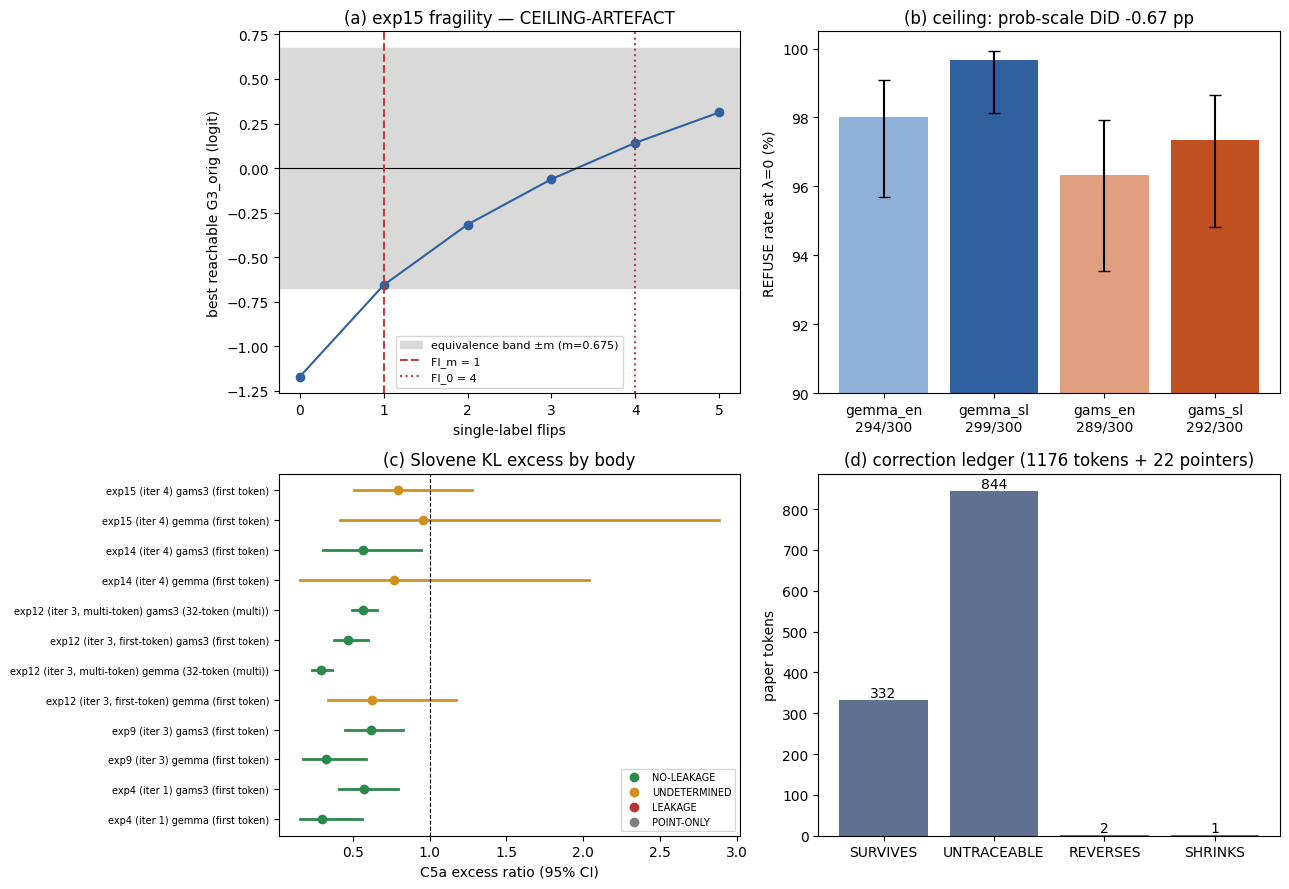

In [15]:
ma = out["metrics_agg"]
groups = {"(1) ceiling / exp15 G3_orig": "exp15_", "eval3 bodies (gemini readout)": "eval3_", "(2) C5a KL excess": "kl_",
          "(3) decomposition": "decomp_", "(4) exp14 tables": "exp14_", "(5) criterion shift": "crit_",
          "ledger": "ledger_", "exp13": "exp13_", "verification": "verify_"}
for g, pre in groups.items():
    print(f"\n== {g}")
    for kk, vv in ma.items():
        if kk.startswith(pre):
            print(f"  {kk:<42s} {vv: .4f}")

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
# (a) fragility trajectory
tr = fi["trajectory"]
ax[0, 0].plot([t["flips"] for t in tr], [t["best_G3_orig"] for t in tr], "o-", color="#3060a0")
ax[0, 0].axhspan(-M, M, color="0.85", label=f"equivalence band ±m (m={M})")
ax[0, 0].axhline(0, color="k", lw=0.8)
ax[0, 0].axvline(fi["FI_m"], ls="--", color="#c04040", label=f"FI_m = {fi['FI_m']}")
ax[0, 0].axvline(fi["FI_0"], ls=":", color="#c04040", label=f"FI_0 = {fi['FI_0']}")
ax[0, 0].set(xlabel="single-label flips", ylabel="best reachable G3_orig (logit)", title=f"(a) exp15 fragility — {verdict}")
ax[0, 0].legend(fontsize=8)
# (b) lambda-0 refusal rates with Wilson CIs
labs, ps, los, his = [], [], [], []
for cc in CELLS:
    p = k[cc] / n[cc]
    lo_, hi_ = wilson(k[cc], n[cc])
    labs.append(f"{cc}\n{int(k[cc])}/{int(n[cc])}"); ps.append(100 * p); los.append(100 * (p - lo_)); his.append(100 * (hi_ - p))
ax[0, 1].bar(labs, ps, yerr=[los, his], color=["#8fb0d8", "#3060a0", "#e0a080", "#c05020"], capsize=4)
ax[0, 1].set_ylim(90, 100.5)
ax[0, 1].set(ylabel="REFUSE rate at λ=0 (%)", title=f"(b) ceiling: prob-scale DiD {did_pp:.2f} pp")
# (c) KL excess forest plot
kl_rows = [r for r in RESULTS["kl_excess"]["reconciliation"]["rows"] if "point" in r]
colors = {"NO-LEAKAGE": "#2a8a4a", "UNDETERMINED": "#d09020", "LEAKAGE": "#c03030", "POINT-ONLY": "0.5"}
for i, r in enumerate(kl_rows):
    ci = r.get("ci95")
    if ci:
        ax[1, 0].plot(ci, [i, i], color=colors.get(r["verdict"], "k"), lw=2)
    ax[1, 0].plot(r["point"], i, "o", color=colors.get(r["verdict"], "k"))
ax[1, 0].axvline(1, color="k", ls="--", lw=0.8)
ax[1, 0].set_yticks(range(len(kl_rows)))
ax[1, 0].set_yticklabels([f"{r['body']} {r['model'].split('_')[0]} ({r['horizon']})"[:52] for r in kl_rows], fontsize=7)
ax[1, 0].set(xlabel="C5a excess ratio (95% CI)", title="(c) Slovene KL excess by body")
for vname, col in colors.items():
    ax[1, 0].plot([], [], "o", color=col, label=vname)
ax[1, 0].legend(fontsize=7, loc="lower right")
# (d) ledger status counts
cbs = RESULTS["correction_ledger"]["counts_by_status"]
ax[1, 1].bar(list(cbs), list(cbs.values()), color="#607090")
for i, vv in enumerate(cbs.values()):
    ax[1, 1].text(i, vv, str(vv), ha="center", va="bottom")
ax[1, 1].set(ylabel="paper tokens", title=f"(d) correction ledger ({ma['ledger_tokens']:.0f} tokens + {ma['ledger_pointers']:.0f} pointers)")
plt.tight_layout()
plt.show()